### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)

### Load and Display Data

In [2]:
df = pd.read_csv("diabetic_data.csv")
print("Shape:", df.shape)
print("\nTarget distribution:")
print(df["readmitted"].value_counts())
print(f"\nReadmission rate (<30 days): {(df['readmitted']=='<30').mean()*100:.1f}%")

Shape: (101766, 50)

Target distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Readmission rate (<30 days): 11.2%


### Discover hidden missing values

In [3]:
# Dataset uses '?' for missing — replace with NaN
df.replace("?", np.nan, inplace=True)

# Check real missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(
    "Missing %", ascending=False
)
print(missing_df)

                   Missing Count  Missing %
weight                     98569      96.86
max_glu_serum              96420      94.75
A1Cresult                  84748      83.28
medical_specialty          49949      49.08
payer_code                 40256      39.56
race                        2273       2.23
diag_3                      1423       1.40
diag_2                       358       0.35
diag_1                        21       0.02


### Visualize missing values

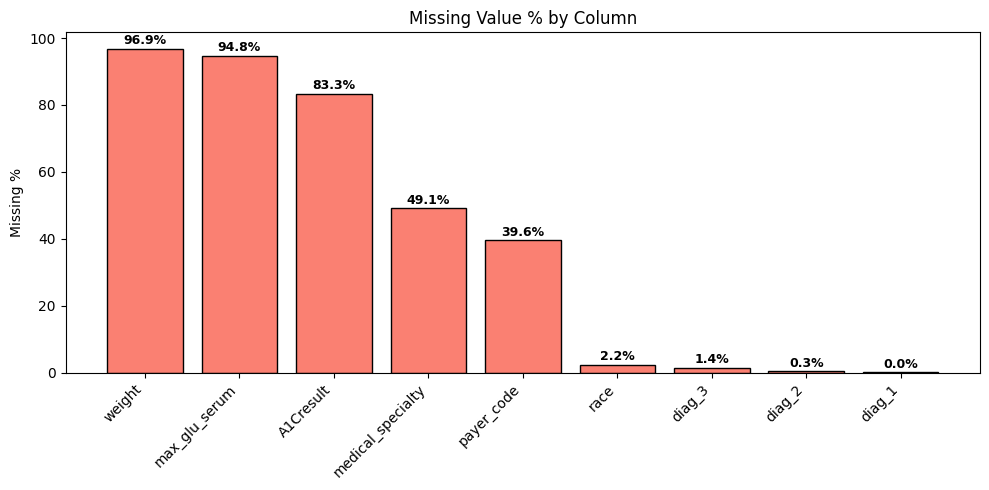

In [5]:
plt.figure(figsize=(10, 5))
bars = plt.bar(
    missing_df.index, missing_df["Missing %"], color="salmon", edgecolor="black"
)

for bar, pct in zip(bars, missing_df["Missing %"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.title("Missing Value % by Column")
plt.ylabel("Missing %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("images/missing_values.png")
plt.show()

###  Target variable distribution

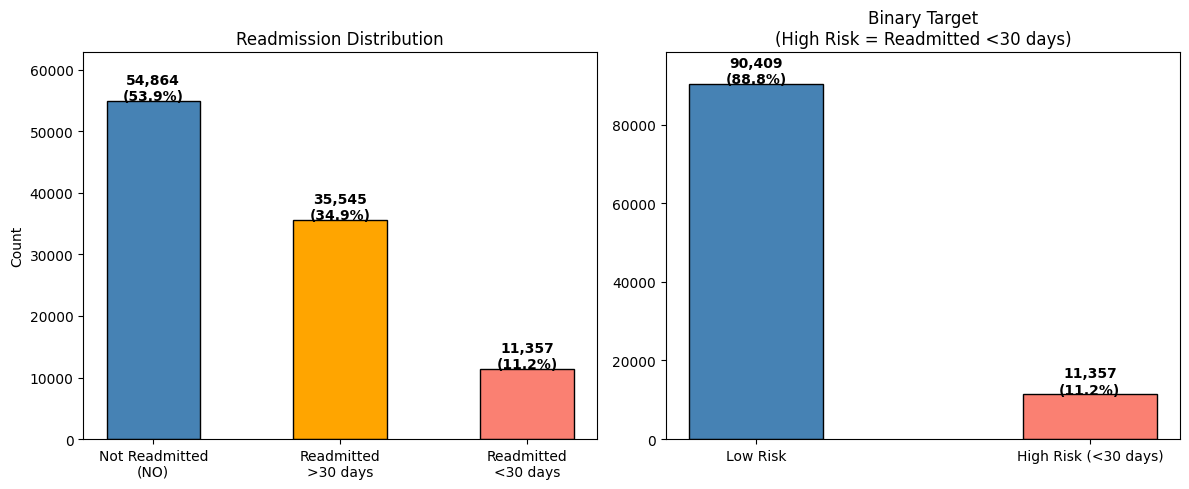

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df["readmitted"].value_counts()
bars = axes[0].bar(
    ["Not Readmitted\n(NO)", "Readmitted\n>30 days", "Readmitted\n<30 days"],
    counts.values,
    color=["steelblue", "orange", "salmon"],
    edgecolor="black",
    width=0.5,
)

for bar, count in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{count:,}\n({count/len(df)*100:.1f}%)",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

axes[0].set_title("Readmission Distribution")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, max(counts.values) + 8000)

# Binary target (what we'll predict)
df["high_risk"] = (df["readmitted"] == "<30").astype(int)
binary_counts = df["high_risk"].value_counts().sort_index()
axes[1].bar(
    ["Low Risk", "High Risk (<30 days)"],
    binary_counts.values,
    color=["steelblue", "salmon"],
    edgecolor="black",
    width=0.4,
)

for bar, count in zip(axes[1].patches, binary_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{count:,}\n({count/len(df)*100:.1f}%)",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

axes[1].set_title("Binary Target\n(High Risk = Readmitted <30 days)")
axes[1].set_ylim(0, max(binary_counts.values) + 8000)

plt.tight_layout()
plt.savefig("images/target_distribution.png")
plt.show()

### Key numeric features distribution

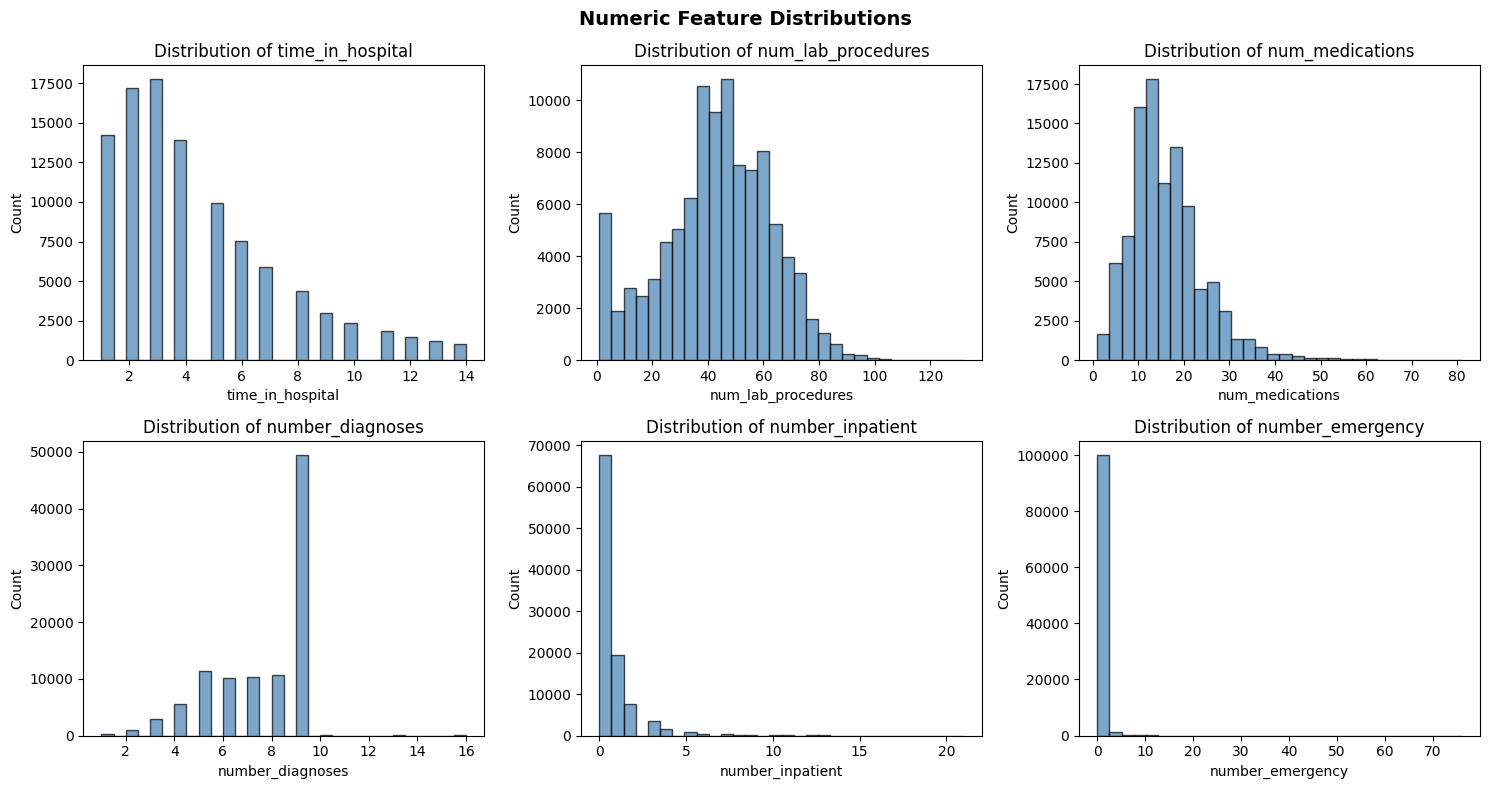

In [7]:
numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_diagnoses",
    "number_inpatient",
    "number_emergency",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.suptitle("Numeric Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("images/numeric_distributions.png")
plt.show()

### Age vs Readmission

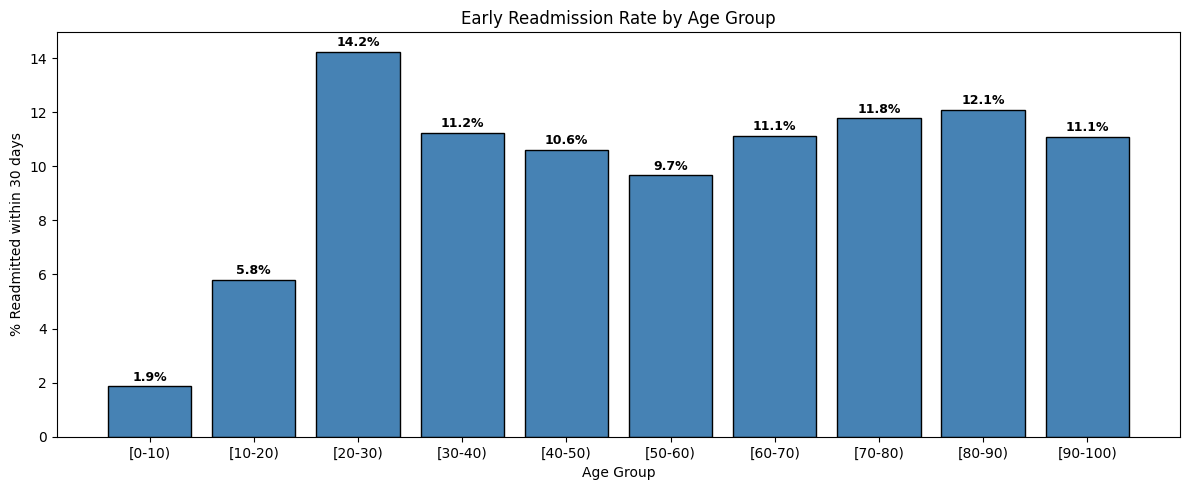

In [8]:
age_order = [
    "[0-10)",
    "[10-20)",
    "[20-30)",
    "[30-40)",
    "[40-50)",
    "[50-60)",
    "[60-70)",
    "[70-80)",
    "[80-90)",
    "[90-100)",
]

age_risk = df.groupby("age")["high_risk"].mean() * 100
age_risk = age_risk.reindex(age_order)

plt.figure(figsize=(12, 5))
bars = plt.bar(age_risk.index, age_risk.values, color="steelblue", edgecolor="black")

for bar, val in zip(bars, age_risk.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.title("Early Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("% Readmitted within 30 days")
plt.tight_layout()
plt.savefig("images/age_vs_readmission.png")
plt.show()

### Correlation heatmap (numeric only)

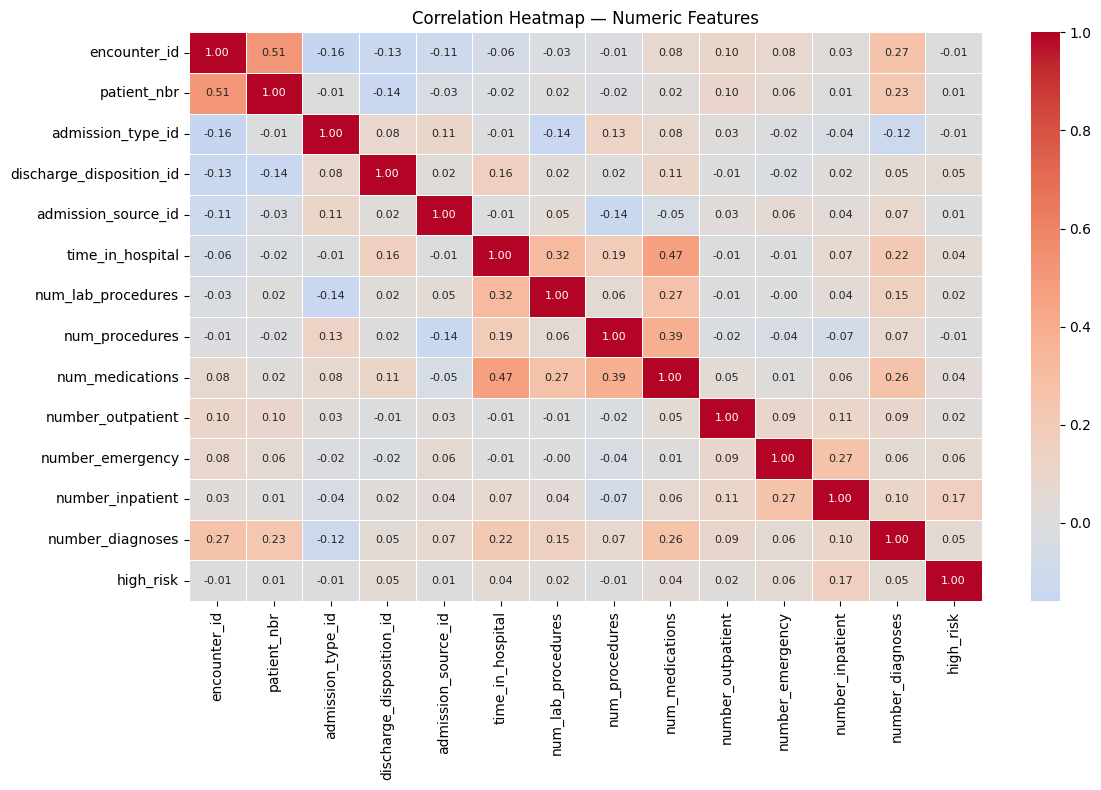

In [9]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8},
)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png")
plt.show()

## Day 1 EDA Summary

### Dataset Overview
- 101,766 patient encounters × 50 features
- Real-world hospital data from 130 US hospitals (1999-2008)

### Target Variable
- Predicting early readmission (<30 days) — binary classification
- Class imbalance: only 11.2% are high risk — will need SMOTE

### Key Missing Values
- weight: 97% missing — will DROP this column
- payer_code: 40% missing — will DROP
- medical_specialty: 49% missing — will DROP
- max_glu_serum & A1Cresult: high missing — will impute with mode

### Key Findings
- Dataset uses '?' for missing values — replaced with NaN
- Significant class imbalance (11.2% positive class)
- Next: Feature engineering & cleaning